# r/gradadmissions — September 2024 Topic + Sentiment Analysis

This notebook runs **Topic Modeling** and **Sentiment Analysis** separately for the **September 2024** dataset from **r/gradadmissions**.

## What you'll get
### Topic modeling (LDA)
- Preprocess text (title + body)
- Train LDA (e.g., 5–6 topics)
- Visualize topic prevalence
- Inspect top words per topic (so you can label topics)

### Sentiment analysis (VADER)
- Compute sentiment scores (compound ∈ [-1, 1])
- Plot sentiment distribution and positive/neutral/negative share
- Identify **which topic is most negative** (avg sentiment + % negative)

---
## Expected input
A CSV (or JSONL) containing Reddit posts with at least:
- `created_utc` (timestamp or datetime)
- `title`
- `selftext` (post body)

If your column names differ, adjust in **Step 1**.


## 0) Install/Import

If you run this in a fresh environment, you may need to install VADER:

```bash
pip install vaderSentiment
```

If you're on Colab:

```bash
!pip install vaderSentiment
```


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import re
from datetime import datetime, timezone

pd.set_option('display.max_colwidth', 200)


## 1) Load your dataset

Set the path to your September 2024 dataset file.

- If your file contains **multiple months**, this notebook will filter for **September 2024**.
- If your file is already only September 2024, filtering will keep everything.


In [5]:
# TODO: Update this path
DATA_PATH = 'r_gradadmissions_posts.cleaned.jsonl'   # <-- change filename

# If JSONL
df = pd.read_json(DATA_PATH, lines=True)

# ---- Column mapping (adjust if needed) ----
# Expected columns: created_utc (timestamp), title, selftext
CREATED_COL = 'created_utc'
TITLE_COL = 'title'
BODY_COL = 'selftext'

print('Rows:', len(df))
print('Columns:', df.columns.tolist())
df.head(3)

Rows: 88441
Columns: ['record_id', 'kind', 'subreddit', 'author', 'created_utc', 'created_date', 'score', 'num_comments', 'title', 'selftext', 'body', 'clean_text', 'degree_type', 'outcome']


,record_id,kind,subreddit,author,created_utc,created_date,score,num_comments,title,selftext,body,clean_text,degree_type,outcome
0,15ex9yw,post,gradadmissions,ArmLongjumping3965,1690850342,2023-08-01,1,0,Master's in engineering holder looking to learn more physics and pure maths,"I have a Master's in information and computer engineering from Cambridge with pretty good grades. In my first year of university I was a Natural Sciences student studying physics, chemistry and ma...",,Master's in engineering holder looking to learn more physics and pure maths I have a Master's in information and computer engineering from Cambridge with pretty good grades. In my first year of un...,Masters,Unknown
1,15eyary,post,gradadmissions,minefourth,1690853103,2023-08-01,1,0,Is the gre a better path to pursue than enrolling in a graduate certificate,[removed],,Is the gre a better path to pursue than enrolling in a graduate certificate [removed],Other,Unknown
2,15ezubg,post,gradadmissions,Sherlock-1899,1690857397,2023-08-01,2,0,Can I get into a good college with 2 backlogs?,I had to clear 2 subjects in the second attempt as I missed the first attempt because of an emergency travel situation. I am worried this might affect my chances of getting into a good uni for mas...,,Can I get into a good college with 2 backlogs? I had to clear 2 subjects in the second attempt as I missed the first attempt because of an emergency travel situation. I am worried this might affec...,Masters,Unknown


## 2) Filter to September 2024

This handles:
- Unix timestamps (seconds)
- ISO datetime strings


In [6]:
def to_datetime_utc(x):
    """Convert created_utc to timezone-aware UTC datetime."""
    if pd.isna(x):
        return pd.NaT
    # If numeric, assume unix seconds
    if isinstance(x, (int, float, np.integer, np.floating)):
        try:
            return datetime.fromtimestamp(float(x), tz=timezone.utc)
        except Exception:
            return pd.NaT
    # If string, try parse
    try:
        dt = pd.to_datetime(x, utc=True, errors='coerce')
        if pd.isna(dt):
            return pd.NaT
        # Ensure tz-aware
        if dt.tzinfo is None:
            dt = dt.tz_localize('UTC')
        return dt.to_pydatetime()
    except Exception:
        return pd.NaT

df['created_dt'] = df[CREATED_COL].apply(to_datetime_utc)
df = df.dropna(subset=['created_dt'])

# Filter Sept 2024 inclusive
start = datetime(2024, 9, 1, tzinfo=timezone.utc)
end = datetime(2024, 10, 1, tzinfo=timezone.utc)
sept = df[(df['created_dt'] >= start) & (df['created_dt'] < end)].copy()

print('September 2024 rows:', len(sept))
sept[['created_dt', TITLE_COL, BODY_COL]].head(3)


September 2024 rows: 2190


,created_dt,title,selftext
44587,2024-09-01 00:47:40+00:00,"Apply to Masters of Statistics, Should I Switch My Major?","Hi All, I am looking for some advise. For some perspective I am currently entering my 5th year (due to scheduling conflicts) of a Bachelor of Science in Mathematics and Economics with a concentrat..."
44588,2024-09-01 01:51:10+00:00,Chronic pain and illness,"Hello, I find myself in a grim position. I want to pursue a PhD in social personality psychology. I have dealt with a chronic pain condition for upwards of ten years and only just got diagnosed an..."
44589,2024-09-01 02:12:13+00:00,MS in Cs for spring purdue,[removed]


## 3) Prepare text field (title + body)

We create one text column used for both topic modeling and sentiment.


In [7]:
sept[TITLE_COL] = sept[TITLE_COL].fillna('')
sept[BODY_COL] = sept[BODY_COL].fillna('')

sept['text_raw'] = (sept[TITLE_COL].astype(str) + ' ' + sept[BODY_COL].astype(str)).str.strip()
sept = sept[sept['text_raw'].str.len() > 0].copy()
# Remove deleted/removed posts
sept = sept[~sept[BODY_COL].isin(['[deleted]', '[removed]'])]

# Remove very short posts (helps LDA)
sept = sept[sept['text_raw'].str.len() > 20]

print('Non-empty text rows:', len(sept))
sept[['text_raw']].head(3)


Non-empty text rows: 1908


,text_raw
44587,"Apply to Masters of Statistics, Should I Switch My Major? Hi All, I am looking for some advise. For some perspective I am currently entering my 5th year (due to scheduling conflicts) of a Bachelor..."
44588,"Chronic pain and illness Hello, I find myself in a grim position. I want to pursue a PhD in social personality psychology. I have dealt with a chronic pain condition for upwards of ten years and o..."
44591,"Need an acceptance letter for a Master's degree in the next 14 days or I'll have to enter mandatory military service. Help! Hi everyone, I'm in a really urgent and desperate situation. I recently ..."


# PART A — Topic Modeling (LDA)

## A1) Text cleaning (lightweight)

We remove URLs and non-letters. Keep it simple for a first pass.


In [8]:
url_re = re.compile(r'https?://\S+|www\.\S+')
non_letter_re = re.compile(r'[^a-zA-Z\s]')

def clean_for_topics(s: str) -> str:
    s = s.lower()
    s = url_re.sub(' ', s)
    s = non_letter_re.sub(' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

sept['text_topics'] = sept['text_raw'].astype(str).apply(clean_for_topics)
sept[['text_topics']].head(3)


,text_topics
44587,apply to masters of statistics should i switch my major hi all i am looking for some advise for some perspective i am currently entering my th year due to scheduling conflicts of a bachelor of sci...
44588,chronic pain and illness hello i find myself in a grim position i want to pursue a phd in social personality psychology i have dealt with a chronic pain condition for upwards of ten years and only...
44591,need an acceptance letter for a master s degree in the next days or i ll have to enter mandatory military service help hi everyone i m in a really urgent and desperate situation i recently graduat...


## A2) Vectorize + Train LDA

- `n_topics`: start with 5 or 6
- `min_df` / `max_df`: helps remove extremely rare/common terms


In [9]:
n_topics = 5  # TODO: try 5 or 6

vectorizer = CountVectorizer(
    stop_words='english',
    min_df=3,          # was 5
    max_df=0.90,       # was 0.95
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(sept['text_topics'])
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method='batch'
)
topic_dist = lda.fit_transform(X)  # rows: docs, cols: topics

sept['topic_id'] = topic_dist.argmax(axis=1)
sept['topic_conf'] = topic_dist.max(axis=1)

sept[['topic_id', 'topic_conf']].head(5)


,topic_id,topic_conf
44587,2,0.448416
44588,0,0.992153
44591,2,0.649271
44593,1,0.551255
44594,2,0.986323


## A3) Inspect top words per topic

Use this table to manually label topics (e.g., "Funding", "SOP", "GRE", "GPA", "International", "Interviews").


In [10]:
def top_words_per_topic(model, feature_names, n_top_words=12):
    rows = []
    for topic_idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[:-n_top_words-1:-1]
        words = [feature_names[i] for i in top_idx]
        rows.append({'topic_id': topic_idx, 'top_terms': ', '.join(words)})
    return pd.DataFrame(rows)

topic_terms = top_words_per_topic(lda, vectorizer.get_feature_names_out(), n_top_words=12)
topic_terms


,topic_id,top_terms
0,0,"research, phd, want, like, just, programs, school, applying, ve, know, work, experience"
1,1,"phd, research, experience, programs, apply, biology, applying, years, application, year, student, master"
2,2,"university, programs, master, science, masters, program, phd, universities, degree, engineering, computer, like"
3,3,"gre, profile, gpa, score, universities, research, experience, university, fall, ms, college, cs"
4,4,"school, grad, application, grad school, applying, program, year, lor, university, letter, gpa, wes"


## A4) Visualize topic prevalence

Bar chart: which topics are most common in September 2024?


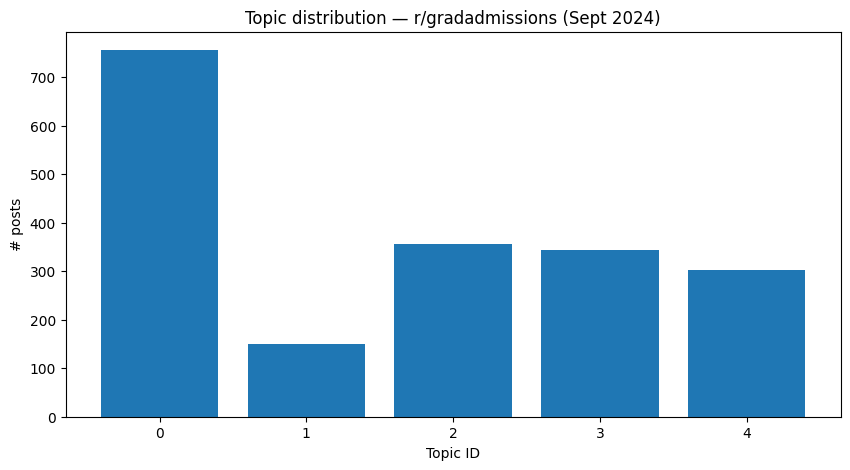

,count
topic_id,
0,756
1,149
2,357
3,343
4,303


In [11]:
topic_counts = sept['topic_id'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(topic_counts.index.astype(str), topic_counts.values)
plt.title('Topic distribution — r/gradadmissions (Sept 2024)')
plt.xlabel('Topic ID')
plt.ylabel('# posts')
plt.show()

topic_counts.to_frame('count')


# PART B — Sentiment Analysis (VADER)

## B1) Compute sentiment (compound ∈ [-1, 1])

- compound > 0.05 → positive
- compound < -0.05 → negative
- otherwise → neutral


In [12]:
analyzer = SentimentIntensityAnalyzer()

def vader_compound(s: str) -> float:
    if not isinstance(s, str) or len(s.strip()) == 0:
        return np.nan
    return analyzer.polarity_scores(s)['compound']

sept['sent_compound'] = sept['text_raw'].astype(str).apply(vader_compound)
sept = sept.dropna(subset=['sent_compound']).copy()

def sentiment_label(c: float) -> str:
    if c > 0.05:
        return 'positive'
    if c < -0.05:
        return 'negative'
    return 'neutral'

sept['sent_label'] = sept['sent_compound'].apply(sentiment_label)
sept[['sent_compound', 'sent_label']].head(5)


,sent_compound,sent_label
44587,0.2808,positive
44588,0.8735,positive
44591,0.9849,positive
44593,0.6369,positive
44594,0.9566,positive


## B2) Sentiment range + distribution


Sentiment (compound) range: -0.9928 to 0.9998
Mean compound: 0.5385249999999999


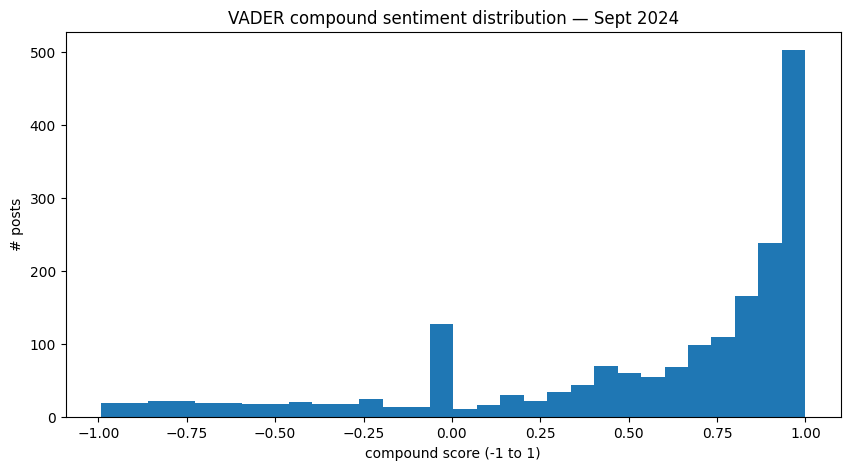

In [13]:
sent_min = sept['sent_compound'].min()
sent_max = sept['sent_compound'].max()
sent_mean = sept['sent_compound'].mean()

print('Sentiment (compound) range:', sent_min, 'to', sent_max)
print('Mean compound:', sent_mean)

plt.figure(figsize=(10, 5))
plt.hist(sept['sent_compound'], bins=30)
plt.title('VADER compound sentiment distribution — Sept 2024')
plt.xlabel('compound score (-1 to 1)')
plt.ylabel('# posts')
plt.show()


## B3) Positive / Neutral / Negative share


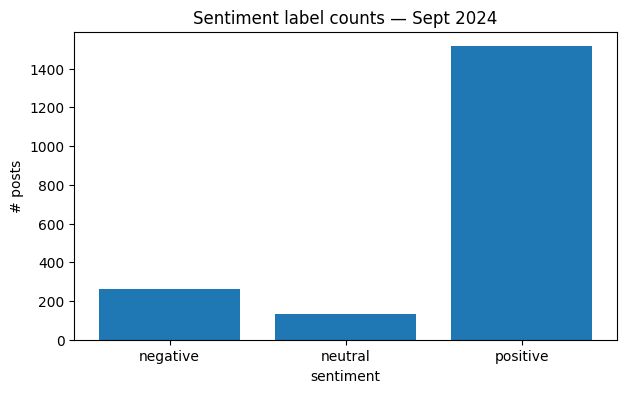

,count,proportion
sent_label,,
negative,261,0.137
neutral,132,0.069
positive,1515,0.794


In [14]:
sent_counts = sept['sent_label'].value_counts().reindex(['negative', 'neutral', 'positive']).fillna(0).astype(int)
sent_props = (sent_counts / sent_counts.sum()).round(3)

plt.figure(figsize=(7, 4))
plt.bar(sent_counts.index, sent_counts.values)
plt.title('Sentiment label counts — Sept 2024')
plt.xlabel('sentiment')
plt.ylabel('# posts')
plt.show()

pd.DataFrame({'count': sent_counts, 'proportion': sent_props})


## B4) Which topic is most negative?

We compute for each topic:
- average compound sentiment
- % of posts labeled negative

Then we identify the "most negative" topic.


In [15]:
topic_sent_summary = sept.groupby('topic_id').agg(
    posts=('topic_id', 'size'),
    avg_compound=('sent_compound', 'mean'),
    pct_negative=('sent_label', lambda x: (x == 'negative').mean())
).reset_index()

topic_sent_summary['pct_negative'] = (topic_sent_summary['pct_negative'] * 100).round(1)
topic_sent_summary['avg_compound'] = topic_sent_summary['avg_compound'].round(3)

topic_sent_summary.sort_values(['avg_compound', 'pct_negative']).reset_index(drop=True)


,topic_id,posts,avg_compound,pct_negative
0,4,303,0.281,24.4
1,1,149,0.471,12.8
2,0,756,0.546,17.2
3,3,343,0.630,7.9
4,2,357,0.681,3.1


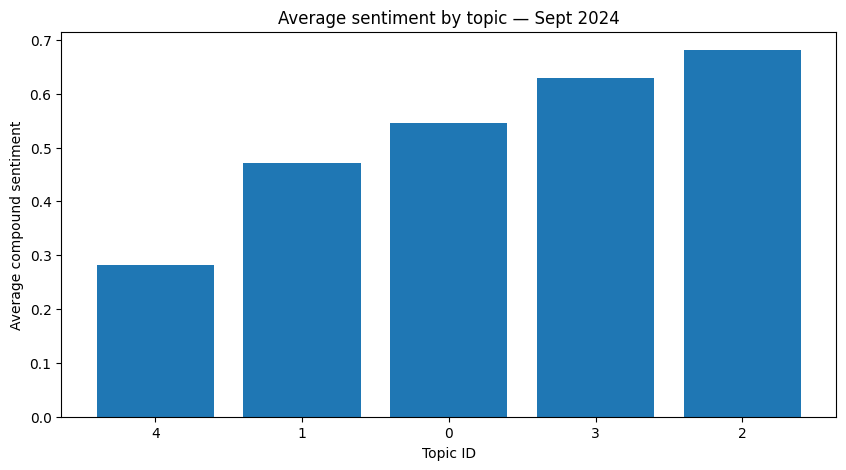

In [16]:
# Visualization: topic vs average sentiment
tmp = topic_sent_summary.sort_values('avg_compound')

plt.figure(figsize=(10, 5))
plt.bar(tmp['topic_id'].astype(str), tmp['avg_compound'])
plt.title('Average sentiment by topic — Sept 2024')
plt.xlabel('Topic ID')
plt.ylabel('Average compound sentiment')
plt.show()


## B5) Inspect examples from the most negative topic

This helps you write qualitative support (a few example posts) without quoting too much.


In [17]:
most_negative_topic = topic_sent_summary.sort_values(['avg_compound', 'pct_negative']).iloc[0]['topic_id']
print('Most negative topic_id:', most_negative_topic)

examples = sept[sept['topic_id'] == most_negative_topic].sort_values('sent_compound').head(10)
examples[[ 'created_dt', TITLE_COL, 'sent_compound', 'sent_label', 'topic_conf']]


Most negative topic_id: 4.0


,created_dt,title,sent_compound,sent_label,topic_conf
46016,2024-09-20 19:38:49+00:00,Can I still get into grad school if my high school counselor kind of screwed me...?,-0.9706,negative,0.598731
45255,2024-09-10 02:50:11+00:00,Did I ruin my professional relationship with my professor? Seeking advice.,-0.9538,negative,0.499593
45916,2024-09-19 04:57:52+00:00,calculating my GPA for Master Programs?,-0.9271,negative,0.839514
45672,2024-09-16 03:15:01+00:00,Mistakenly submitted my Texas A&M SOP to Northeastern - Will this Ruin My Aoolication?,-0.9215,negative,0.973718
45793,2024-09-17 17:15:01+00:00,Will High School Haunt Me?,-0.9152,negative,0.471021
45601,2024-09-14 23:46:38+00:00,I reached out to a phd advisor before realizing they said not to do this on the website. Am I screwed?,-0.9100,negative,0.629576
44814,2024-09-03 23:25:36+00:00,Unsure what do after rejection,-0.8703,negative,0.711740
46070,2024-09-21 17:28:44+00:00,Would a C in physics hurt my chances of getting into bio grad school?,-0.8608,negative,0.657389
44614,2024-09-01 14:18:12+00:00,Doubts regarding my application,-0.8481,negative,0.829495
45139,2024-09-08 14:31:06+00:00,Enrolment Deposit Conundrum,-0.8442,negative,0.500197
